In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import NullFormatter
import pickle as pk
%matplotlib inline


In [2]:

with (open(r"..\results\imps_analytic_prediction_summary_data.pkl", "rb")) as openfile:
    data = pk.load(openfile)
        

In [3]:
inf_values_data = data["inf_values"]
inf_values = list(inf_values_data.values())
inf_values_ar = np.zeros((4,10))
for i in range(4):
    for j in range(10):
        inf_values_ar[i,j]=inf_values[i*j]
inf_values_ar[:,2]
analytics=np.array(data["q_at"][0.2])/(0.2**2)

In [4]:
finite_values_data = data["finite_values"]
finite_values_data



{(0, 4): 0.0007099018045422939,
 (0, 8): 0.0007109345169920314,
 (0, 12): 0.000712684813853316,
 (0, 16): 0.000713138119244137,
 (0, 20): 0.0006944489692493819,
 (1, 4): 0.001302574017680238,
 (1, 8): 0.0013059248173555623,
 (1, 12): 0.001313858830659757,
 (1, 16): 0.0013396900840307122,
 (1, 20): 0.0012666986991341053,
 (2, 4): 0.0007006746562723482,
 (2, 8): 0.0007015241064916799,
 (2, 12): 0.0007031605211027239,
 (2, 16): 0.0007120403175114281,
 (2, 20): 0.000767700490188409,
 (3, 4): 0.0009888659206536894,
 (3, 8): 0.000990858862165128,
 (3, 12): 0.000994459930353028,
 (3, 16): 0.000998322063263032,
 (3, 20): 0.0010090809430809819,
 (4, 4): 0.000653627921344242,
 (4, 8): 0.0006545257278940328,
 (4, 12): 0.0006557697548875234,
 (4, 16): 0.0006646370648341791,
 (4, 20): 0.0006474901376872425,
 (5, 4): 0.0017827589862564402,
 (5, 8): 0.0017892534692524034,
 (5, 12): 0.0017997947141985325,
 (5, 16): 0.0018191999866237684,
 (5, 20): 0.0017941905603745657,
 (6, 4): 0.002772222642772993,


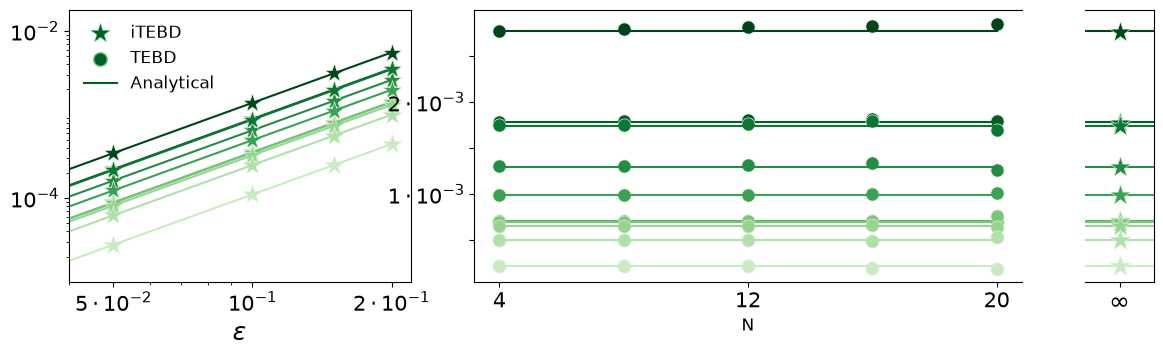

In [5]:
fig, ax = plt.subplots(1,3, figsize = (14,4),gridspec_kw={"width_ratios": [1, 1.6,0.2]})
colors = plt.get_cmap("Greens")(np.linspace(0.15, 1.0, 11))
sorting =  np.argsort(np.argsort(analytics))
x_values = sorted({key[0] for key in inf_values_data})
epsilon = np.linspace(0,0.2,300)
for i in range(10):
    ax[0].scatter(x_values, [inf_values_data[(x, i)] for x in x_values],
             marker="*", color = colors[1+sorting[i]],edgecolor=colors[0], linewidth = 0.5, s = 200)
    ax[0].plot(epsilon,epsilon**2*analytics[i]/4,color = colors[1+sorting[i]],zorder=1)


   #for legend
ax[0].scatter([0], 1000,
                 marker="*", color = colors[1+sorting[5]],edgecolor=colors[5], label = "iTEBD", linewidth = 0.5, s = 200)
ax[0].scatter([0], 1000,
                 marker="o", color = colors[1+sorting[5]],edgecolor=colors[5], label = "TEBD", linewidth = 1, s = 90)
ax[0].plot(epsilon,1000+epsilon,color = colors[1+sorting[5]],label = "Analytical",zorder=1)
    
ax[0].set_yscale("log")
ax[0].set_xscale("log")

ax[0].set_ylim(10**-5,1.8*10**-2)
ax[0].legend(fontsize = 12, frameon = False)
ax[0].set_yticks([1e-4,1e-2])
ax[0].set_yticklabels([r"$10^{-4}$",r"$10^{-2}$"], fontsize =15)


ax[0].set_xticks([5e-2,1e-1,2e-1])
ax[0].set_xticklabels([r"$5\cdot 10^{-2}$",r"$10^{-1}$",r"$2\cdot 10^{-1}$"],fontsize = 15)
ax[0].xaxis.set_minor_formatter(NullFormatter())
ax[0].set_xlim(0.04,0.22)
ax[0].set_xlabel(r"$\epsilon$", fontsize = 18)

x_values = sorted({key[1] for key in finite_values_data})
sizes = [4,8,12,16,20]
for i in range(10):
    ax[1].scatter(sizes, [finite_values_data[(i, x)] for x in x_values],
             marker="o", color = colors[1+sorting[i]],edgecolor=colors[0], linewidth = 0.5, s = 90)
    ax[1].plot(sizes,0.2**2*analytics[i]/8*np.ones_like(sizes),color = colors[1+sorting[i]],zorder=1)

ax[1].spines["right"].set_visible(False)
ax[1].set_yticks([])
ax[1].set_xticks([4,12,20])
ax[1].set_xticklabels(["4","12","20"],fontsize = 15)
ax[1].set_xlabel("N", fontsize = 12)
ax[1].set_ylim(0.00005,0.003)
ax[1].tick_params(right=False, labelright=False, left=True, labelleft=True)
ax[1].set_yticks([0.0005,0.001,0.0015,0.002,0.0025])
ax[1].set_yticklabels(["",r"$1\cdot 10^{-3}$","",r"$2\cdot 10^{-3}$",""], fontsize = 15)


ax[2].tick_params(right=True, labelright=True, left=False, labelleft=False)
ax[2].set_yticks([])
ax[2].set_yticklabels([], fontsize = 15)


ax[2].set_xlim(-0.5, 0.5)
ax[2].set_xticks([0])
ax[2].spines["left"].set_visible(False)
ax[2].set_xticklabels([r"$\infty$"],fontsize = 18)
ax[2].set_ylim(0.00005,0.003)

inf_x=np.array([-0.5,0.5])
for i in range(10):
    ax[2].plot(inf_x,0.2**2*analytics[i]/8*np.ones_like(inf_x),color = colors[1+sorting[i]],zorder=1)

for i in range(10):
    ax[2].scatter([0],[0.5*inf_values_data[(0.2, i)]],marker="*", color = colors[1+sorting[i]],edgecolor=colors[0], linewidth = 0.5, s = 250)

out_path = r"..\results\figure_paper.pdf"
fig.subplots_adjust(bottom=0.2)
fig.savefig(out_path, format = "pdf")



